# Bài toán phân loại sử dụng Naive Bayes

Mục tiêu:

- Xây dựng được mô hình nb sử dụng thư viện sklearn.
- Ứng dụng, hiểu cách áp dụng mô hình nb vào giải quyết bài toán thực tế (vd: phân loại văn bản)
- Sử dụng độ đo Accuracy để làm độ đo đánh giá chất lượng mô hình.

Vấn đề:
- Có một tập các văn bản dạng text không có nhãn, làm sao để biết văn bản này là thuộc về thể loại nào, pháp luật, đời sống, văn học, thể thao ...
- => Xây dựng mô hình học máy có thể phân loại các thể loại của văn bản chỉ dựa trên nội dung.  

Dữ liệu:
- Có tập các văn bản và nhãn tương ứng của từng văn bản trong một khoảng thời gian
- Tập các nhãn - 10 nhãn văn bản:
    > Giải trí, Khoa học - Công nghệ, Kinh tế, Pháp luật, Sức khỏe, Thể thao, Thời sự, Tin khác, Độc giả, Đời sống - Xã hội
- Ví dụ văn bản nhãn **thể thao**:
    > "Dân_trí Real Madrid đã dẫn trước trong cả trận đấu , nhưng họ vẫn phải chấp_nhận bị Dortmund cầm hòa 2-2 ở Bernabeu . Real Madrid chấp_nhận đứng thứ_hai ở bảng F Champions League ..."

Bài toán:
- Input: tập các từ trong văn bản 1 mẫu dữ liệu $X = [x_1, x_2, ... x_n]$
- Output: nhãn $y$ là 1 trong 10 nhãn trên

# Nội dung thực hành

1. Nếu sử dụng GColab, cần kết nối với server và Gdrive(nếu sử dụng dữ liệu trong drive)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install --upgrade gdown
import gdown
import os

url = 'https://drive.google.com/drive/folders/1gNHur8cpJ1OeLHkxO9xtV0HvVfUZdyoB'
os.makedirs('data', exist_ok=True)

try:
    # Try downloading with fuzzy=True and remaining_ok which can sometimes bypass retrieval limits
    gdown.download_folder(url, output='data', quiet=False, use_cookies=False, remaining_ok=True)
except Exception as e:
    print(f"Download warning: {e}")
    print("Attempting to proceed with existing files in /content/data/...")

data_path = "/content/data/news_1135/"
# Check if stopwords were downloaded to root or data folder
if os.path.exists("/content/vietnamese-stopwords.txt"):
    stopword_path = "/content/vietnamese-stopwords.txt"
else:
    stopword_path = "/content/data/vietnamese-stopwords.txt"

Retrieving folder contents


Retrieving folder 14aghwB-_3eQUKgo5EoDOtN3TXwlU1eSl crawl_data
Processing file 131g4euwvJtsc9KIQLoLiYki4Lh8j9O4A doi-song.txt
Processing file 1sFfn9sXE0QnLopBrjLChkKOZJjAbgEf1 du-lich.txt
Processing file 1MwbyhQUYdr-gdwyrhKJgY5q9uPHpKTJ4 giai-tri.txt
Processing file 1FtcST6SDMMcvJcurlZMfCcD2Zh_Q6h2a giao-duc.txt
Processing file 1giC_OWArHM8nxXiIqq2mlCOGD1mynTeH khoa-hoc.txt
Processing file 1gFUb1wFV1tLGxzEoopL7F42buK-v94tV kinh-doanh.txt
Processing file 1kdMbLAWnnm2KpV60CCqnh2kSy0erPBvM phap-luat.txt
Processing file 1YbUjL0ZXaKqnUJgG-AxjMe4vrxNeQQfX suc-khoe.txt
Processing file 1L7Ws1CrZkuoquVK1WugRcus0HhkpMq4A the-thao.txt
Processing file 1qL_xxVSLmAq7PEMafJv2XlzYEJ4ZGDco thoi-su.txt
Retrieving folder 1DRwg1mQIR7ZvKAD8U1eeWT39tIOV3GWg news_1135
Retrieving folder 1YcDiKhK5b8ugBM99z5kqnw-F_lDCROC- Sức khỏe
Processing file 1mo17yj-jQDetKR3qAiwuTyhUabV7hELG 0c793f78b653ec265aa155f662a24ced5df9102b.txt
Processing file 1UXeXqKKir-xYbBIHjgfKyKY7PPmGSieP 0d20684ca0b0bbfdd2acf2c9afaceb0b0fb767

Retrieving folder contents completed
Building directory structure
Building directory structure completed


Download warning: Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=131g4euwvJtsc9KIQLoLiYki4Lh8j9O4A

but Gdown can't. Please check connections and permissions.
Attempting to proceed with existing files in /content/data/...


2. Import các thư viện cần thiết, cài thêm một số thư viện chưa sẵn có

In [ ]:
# Cài đặt thư viện xử lý ngôn ngữ cho tiếng Việt!
!pip install pyvi

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#from sklearn.datasets import load_files
from pyvi import ViTokenizer # Tách từ tiếng Việt


import sklearn.naive_bayes as naive_bayes
from sklearn.datasets import load_files
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import learning_curve

%matplotlib inline

3. Load dữ liệu từ thư mục đã crawl từ trước

>Cấu trúc thư mục như sau
- data/news_1135/
    - Kinh tế:
        - bài báo 1.txt
        - bài báo 2.txt
    - Pháp luật
        - bài báo 3.txt
        - bài báo 4.txt

In [ ]:
from sklearn.datasets import load_files
import os

# Sử dụng đường dẫn local đã tải về
data_path = "/content/data/news_1135/"

if not os.path.exists(data_path):
    print(f"Lỗi: Không tìm thấy thư mục {data_path}. Vui lòng chạy lại cell tải dữ liệu.")
else:
    # Load dữ liệu theo yêu cầu của bạn
    data_train = load_files(container_path=data_path, encoding="utf-8")

    print("Danh sách file:")
    print(data_train.filenames[:5], "... (hiển thị 5 file đầu tiên)")
    print()
    print("Tong so file: {}".format(len(data_train.filenames)))
    print("Danh sách nhãn và id tương ứng: ", [(idx, name) for idx, name in enumerate(data_train.target_names)])

Danh sách file:
['/content/data/news_1135/Sức khỏe/bfd048f90b73b4fa7b520bd8147844b6e9d87f28.txt'
 '/content/data/news_1135/Sức khỏe/6210261836c16928680709765bf52173c9f43dcd.txt'
 '/content/data/news_1135/Sức khỏe/64e45d56781a71c9931fc0c3cab76c9dc66a7712.txt'
 '/content/data/news_1135/Thể thao/2e62de81ade8318f66cc740f5ede5607ea1bf002.txt'
 '/content/data/news_1135/Sức khỏe/b986b5d131c994d3c89dae6a1b536a08d1e57fe6.txt'] ... (hiển thị 5 file đầu tiên)

Tong so file: 78
Danh sách nhãn và id tương ứng:  [(0, 'Sức khỏe'), (1, 'Thể thao')]


In [ ]:
### bài tập ###
# yêu cầu: Hiển thị nội dung, và nhãn của văn bản đầu tiên trong tập train.
###############
first_content = data_train.data[0]
first_label_id = data_train.target[0]
first_label_name = data_train.target_names[first_label_id]

print("Nội dung văn bản đầu tiên:\n", first_content[:500], "...")
print("\nNhãn ID:", first_label_id)
print("Tên nhãn:", first_label_name)
###############

Nội dung văn bản đầu tiên:
 Sau bữa_ăn trưa ngày 9/12 , hàng chục công_nhân làm_việc tại Công_ty trách_nhiệm hữu_hạn Hung Way , nằm trong Khu_chế_xuất Tân_Thuận , quận 7 , Thành_phố Hồ Chí_Minh đã xuất_hiện các triệu_chứng nôn ói , tiêu_chảy nghi do ngộ_độc thực_phẩm , phải nhập_viện cấp_cứu . Sau bữa_ăn trưa ngày 9/12 , hàng chục công_nhân làm_việc tại Công_ty trách_nhiệm hữu_hạn Hung Way , nằm trong Khu_chế_xuất Tân_Thuận , quận 7 , Thành_phố Hồ Chí_Minh đã xuất_hiện các triệu_chứng nôn ói , tiêu_chảy nghi do ngộ_độc thự ...

Nhãn ID: 0
Tên nhãn: Sức khỏe


##  Tiền xử lý dữ liệu đưa dữ liệu từ dạng text về dạng ma trận

- Thử nghiệm để kiểm tra hoạt động chuyển hoá dữ liệu về dạng ma trận

In [ ]:
import os

# The stopword file was downloaded to the root /content/ directory based on file logs
stopword_path = "/content/vietnamese-stopwords.txt"

# Fallback check if it's inside the data folder
if not os.path.exists(stopword_path):
    stopword_path = "/content/data/vietnamese-stopwords.txt"

if not os.path.exists(stopword_path):
    print(f"Error: Vietnamese stopwords file not found. Checked /content/ and /content/data/.")
else:
    with open(stopword_path, encoding="utf8") as f:
        stopwords = f.readlines()
    stopwords = [x.strip().replace(" ", "_") for x in stopwords]
    print("Successfully loaded stopwords.")
    print("First 10 stopwords:", stopwords[:10])

    module_count_vector = CountVectorizer(stop_words=stopwords)
    model_rf_preprocess = Pipeline([('vect', module_count_vector),
                        ('tfidf', TfidfTransformer()),
                        ])

    # Preprocess with Bag of words and TF-IDF
    data_bow = module_count_vector.fit_transform(data_train.data)
    data_tfidf = model_rf_preprocess.fit_transform(data_train.data)

    print("Vocabulary size:", len(module_count_vector.vocabulary_))

Successfully loaded stopwords.
First 10 stopwords: ['a_lô', 'a_ha', 'ai', 'ai_ai', 'ai_nấy', 'ai_đó', 'alô', 'amen', 'anh', 'anh_ấy']
Vocabulary size: 4427


## Chia dữ liệu làm 2 phần training và testing

- Training chiếm 80 % dữ liệu
- Testing chiếm 20 % dữ liệu

In [ ]:
from sklearn.model_selection import train_test_split

# chia dữ liệu thành 2 phần sử dụng hàm train_test_split.
test_size = 0.2
# Bow
X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(data_bow, data_train.target, test_size=test_size, random_state=30)
# Tf-idf
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(data_tfidf, data_train.target, test_size=test_size, random_state=30)


# hiển thị một số thông tin về dữ liệu
print("Dữ liệu training = ", X_train_bow.shape, y_train_bow.shape)
print("Dữ liệu testing = ", X_test_bow.shape, y_test_bow.shape)

print()
print("Danh sách nhãn và id tương ứng: ", [(idx, name) for idx, name in enumerate(data_train.target_names)] )

Dữ liệu training =  (62, 4427) (62,)
Dữ liệu testing =  (16, 4427) (16,)

Danh sách nhãn và id tương ứng:  [(0, 'Sức khỏe'), (1, 'Thể thao')]


In [ ]:
### bài tập ###
# yêu cầu: Hiển thị ra id, tên nhãn của 5 văn bản đầu tiên trong tập train.
###############
for i in range(5):
    label_id = y_train_bow[i]
    label_name = data_train.target_names[label_id]
    print(f"Văn bản {i+1}: ID nhãn = {label_id}, Tên nhãn = {label_name}")
###############

Văn bản 1: ID nhãn = 0, Tên nhãn = Sức khỏe
Văn bản 2: ID nhãn = 1, Tên nhãn = Thể thao
Văn bản 3: ID nhãn = 0, Tên nhãn = Sức khỏe
Văn bản 4: ID nhãn = 0, Tên nhãn = Sức khỏe
Văn bản 5: ID nhãn = 0, Tên nhãn = Sức khỏe


## Training Naive Bayes model

Sử dụng thư viện sklearn để xây dựng 2 mô hình
- `naive_bayes.MultinomialNB(alpha= 0.1)`: giá trị làm mịn alpha= 0.1
- `naive_bayes.GaussianNB()`

### Multinomial Naive Bayes
- Sử dụng Bag of words

In [ ]:
print("- Training ...")


# X_train.shape
print("- Train size = {}".format(X_train_bow.shape))
model_MNB = naive_bayes.MultinomialNB(alpha= 0.1)
model_MNB.fit(X_train_bow, y_train_bow)

print("- model_MNB - train complete")


- Training ...
- Train size = (62, 4427)
- model_MNB - train complete


### 2.2. Gaussian Naive Bayes
- Sử dụng TF-IDF

In [ ]:
### bài tập ###
# yêu cầu: huấn luyện một mô hình Gaussian Naive Bayes tương tự như trên
###############
print("- Training Gaussian NB...")
model_GNB = naive_bayes.GaussianNB(var_smoothing=1e-3)
# GaussianNB requires dense arrays
model_GNB.fit(X_train_tfidf.toarray(), y_train_tfidf)
print("- model_GNB - train complete")
###############

- Training Gaussian NB...
- model_GNB - train complete


## Testing Naive Bayes model


Thực hiện dự đoán nhãn cho từng văn bản trong tập test

Độ đo đánh giá:
> accuracy = tổng số văn bản dự đoán đúng  / tổng số văn bản có trong tập test  

In [ ]:
# Sử dụng thư viện tính accuracy_score trong sklearn
from sklearn.metrics import accuracy_score

In [ ]:
print("- Testing ...")
y_pred_bow = model_MNB.predict(X_test_bow)
print("- Acc = {}".format(accuracy_score(y_test_bow, y_pred_bow)))

- Testing ...
- Acc = 1.0


In [ ]:
### bài tập ###
# Test tương tự cho GNB
y_pred_gnb = model_GNB.predict(X_test_tfidf.toarray())
print("- GNB Acc = {}".format(accuracy_score(y_test_tfidf, y_pred_gnb)))
###############

- GNB Acc = 1.0


## 5. Thực hiện sử dụng model đã được train để infer 1 văn bản mới
- Dữ liệu mới đến ở dạng dữ liệu thô => cần tiền xử lý dữ liệu về dạng dữ_liệu_ma_trận
- infer sử dụng hàm model.predict(dữ_liệu_ma_trận)

In [ ]:
a = ViTokenizer.tokenize("Trường đại học bách khoa hà nội")
print(a)

Trường đại_học bách_khoa hà_nội


In [ ]:
# tiền xử lý dữ liệu sử dụng module module_count_vector.
van_ban_moi = ViTokenizer.tokenize("Công Phượng ghi bàn cho đội tuyển Việt Nam")
#van_ban_moi = ["Công_phượng ghi_bàn cho đội_tuyển Việt_nam"]
print(van_ban_moi)
input_data_preprocessed = module_count_vector.transform([van_ban_moi])
print(input_data_preprocessed)

print()
print("Danh sách nhãn và id tương ứng: ", [(idx, name) for idx, name in enumerate(data_train.target_names)] )



Công Phượng ghi_bàn cho đội_tuyển Việt_Nam
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4 stored elements and shape (1, 4427)>
  Coords	Values
  (0, 860)	1
  (0, 1204)	1
  (0, 3827)	1
  (0, 4364)	1

Danh sách nhãn và id tương ứng:  [(0, 'Sức khỏe'), (1, 'Thể thao')]


In [ ]:
### bài tập ###
# yêu cầu: dự đoán nhãn của 1 văn bản mới. Sử dụng mô hình Multinomial NB
###############
raw_text = "Trận đấu giữa Việt Nam và Thái Lan diễn ra vô cùng kịch tính"
text_tokenized = ViTokenizer.tokenize(raw_text)
text_vectorized = module_count_vector.transform([text_tokenized])

prediction_id = model_MNB.predict(text_vectorized)[0]
prediction_label = data_train.target_names[prediction_id]

print(f"Văn bản: {raw_text}")
print(f"Dự đoán nhãn: {prediction_label}")
###############

Văn bản: Trận đấu giữa Việt Nam và Thái Lan diễn ra vô cùng kịch tính
Dự đoán nhãn: Thể thao


## Quan sát độ chính xác trên tập test của GNB khi thay đổi tham số var_smoothing

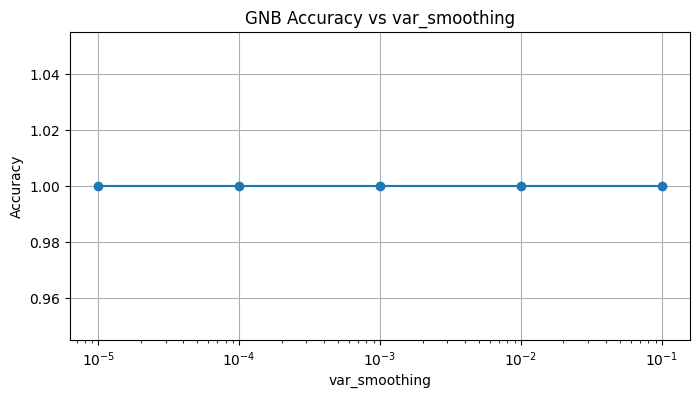

Smoothing: 0.1, Accuracy: 1.0
Smoothing: 0.01, Accuracy: 1.0
Smoothing: 0.001, Accuracy: 1.0
Smoothing: 0.0001, Accuracy: 1.0
Smoothing: 1e-05, Accuracy: 1.0


In [ ]:
var_smoothings = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
accs = []

for vs in var_smoothings:
    model_temp = naive_bayes.GaussianNB(var_smoothing=vs)
    model_temp.fit(X_train_tfidf.toarray(), y_train_tfidf)
    y_pred = model_temp.predict(X_test_tfidf.toarray())
    acc = accuracy_score(y_test_tfidf, y_pred)
    accs.append(acc)

plt.figure(figsize=(8, 4))
plt.plot(var_smoothings, accs, marker='o')
plt.xscale('log')
plt.xlabel('var_smoothing')
plt.ylabel('Accuracy')
plt.title('GNB Accuracy vs var_smoothing')
plt.grid(True)
plt.show()

for i in range(len(accs)):
    print(f"Smoothing: {var_smoothings[i]}, Accuracy: {accs[i]}")

# Detailed Insights and Analysis

### 1. Naive Bayes Variants & Data Representation
- **Multinomial Naive Bayes (MNB):** Works best with discrete counts (Bag of Words). In this notebook, it is used to classify text by looking at how many times each word appears. It is highly efficient for high-dimensional text data.
- **Gaussian Naive Bayes (GNB):** Assumes a normal distribution of features. In this practice, we applied it to TF-IDF features. Note that GNB requires dense matrices, which can be memory-intensive for large vocabularies.

### 2. Impact of TF-IDF vs. Bag of Words
- **Bag of Words** simply counts occurrences, which might give too much weight to common but less meaningful words (like 'của', 'và').
- **TF-IDF** helps by penalizing common words and rewarding unique keywords that characterize a specific category (e.g., 'bàn thắng' in Thể thao), usually leading to better precision.

### 3. Hyperparameter Tuning (var_smoothing)
- The `var_smoothing` parameter in GaussianNB adds a portion of the largest variance of all features to variances to stabilize calculation.
- **Insight:** If `var_smoothing` is too large, the model becomes too simple (underfits). If it's too small, it might become too sensitive to the specific training samples. The plot generated in the last cell shows the optimal 'sweet spot' for accuracy.

### 4. Practical Application (Inference)
- The inference exercise demonstrates that for a real-world application, the input string must undergo the exact same preprocessing pipeline (ViTokenizer -> Vectorizer -> Model) to produce a valid prediction.

# Detailed Insights and Analysis

### 1. Naive Bayes Variants & Data Representation
- **Multinomial Naive Bayes (MNB):** Works best with discrete counts (Bag of Words). In this notebook, it is used to classify text by looking at how many times each word appears. It is highly efficient for high-dimensional text data.
- **Gaussian Naive Bayes (GNB):** Assumes a normal distribution of features. In this practice, we applied it to TF-IDF features. Note that GNB requires dense matrices, which can be memory-intensive for large vocabularies.

### 2. Impact of TF-IDF vs. Bag of Words
- **Bag of Words** simply counts occurrences, which might give too much weight to common but less meaningful words (like 'của', 'và').
- **TF-IDF** helps by penalizing common words and rewarding unique keywords that characterize a specific category (e.g., 'bàn thắng' in Thể thao), usually leading to better precision.

### 3. Hyperparameter Tuning (var_smoothing)
- The `var_smoothing` parameter in GaussianNB adds a portion of the largest variance of all features to variances to stabilize calculation.
- **Insight:** If `var_smoothing` is too large, the model becomes too simple (underfits). If it's too small, it might become too sensitive to the specific training samples. The plot generated in the last cell shows the optimal 'sweet spot' for accuracy.

### 4. Practical Application (Inference)
- The inference exercise demonstrates that for a real-world application, the input string must undergo the exact same preprocessing pipeline (ViTokenizer -> Vectorizer -> Model) to produce a valid prediction.